# **Insurance Charges Analysis & Prediction**

## 1. Load Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

sns.set_palette('colorblind')
print('Libraries loaded!')

Libraries loaded!


## 2. Load Data

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving insurance.csv to insurance (1).csv


In [ ]:
df = pd.read_csv('insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [ ]:
df.describe().round(2)

,age,bmi,children,charges
count,1338.00,1338.00,1338.00,1338.00
mean,39.21,30.66,1.09,13270.42
std,14.05,6.10,1.21,12110.01
min,18.00,15.96,0.00,1121.87
25%,27.00,26.30,0.00,4740.29
50%,39.00,30.40,1.00,9382.03
75%,51.00,34.69,2.00,16639.91
max,64.00,53.13,5.00,63770.43


## 3. Data Cleaning

In [ ]:
print("Missing values:")
print(df.isnull().sum())
print("\nDuplicates:", df.duplicated().sum())

Missing values:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Duplicates: 1


In [ ]:
df = df.drop_duplicates().reset_index(drop=True)
print("Clean shape:", df.shape)

Clean shape: (1337, 7)


In [ ]:
# Outlier Detection — IQR Method
numerical_cols = ['age', 'bmi', 'charges', 'children']

print(f"{'Column':<12} {'Outliers':>10} {'Total':>8} {'Percentage':>12}")
print("=" * 45)

outlier_summary = []
for col in numerical_cols:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    pct = (len(outliers) / len(df)) * 100
    outlier_summary.append({'Column': col, 'Outliers': len(outliers),
                             'Percentage': round(pct, 2)})
    print(f"{col:<12} {len(outliers):>10} {len(df):>8} {pct:>11.2f}%")

outlier_df = pd.DataFrame(outlier_summary)

Column         Outliers    Total   Percentage
age                   0     1337        0.00%
bmi                   9     1337        0.67%
charges             139     1337       10.40%
children              0     1337        0.00%


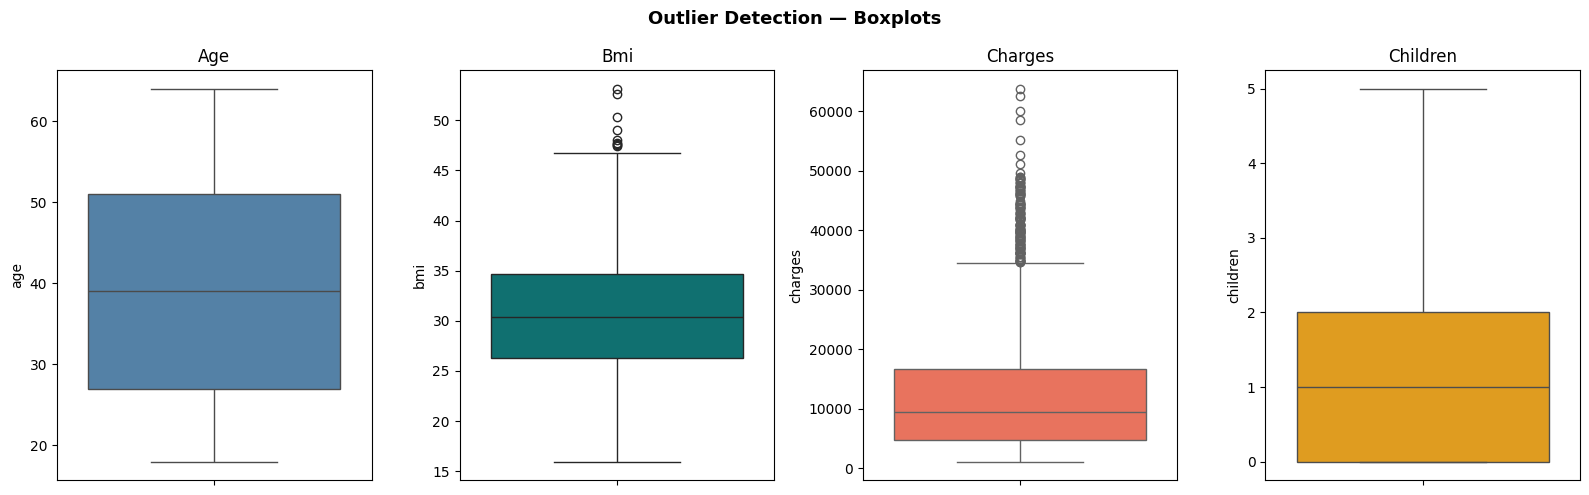

In [ ]:
# Outlier Boxplots
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
colors = ['steelblue', 'teal', 'tomato', 'orange']

for ax, col, color in zip(axes, numerical_cols, colors):
    sns.boxplot(y=df[col], ax=ax, color=color)
    ax.set_title(f'{col.title()}')

plt.suptitle('Outlier Detection — Boxplots', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Univariate Analysis

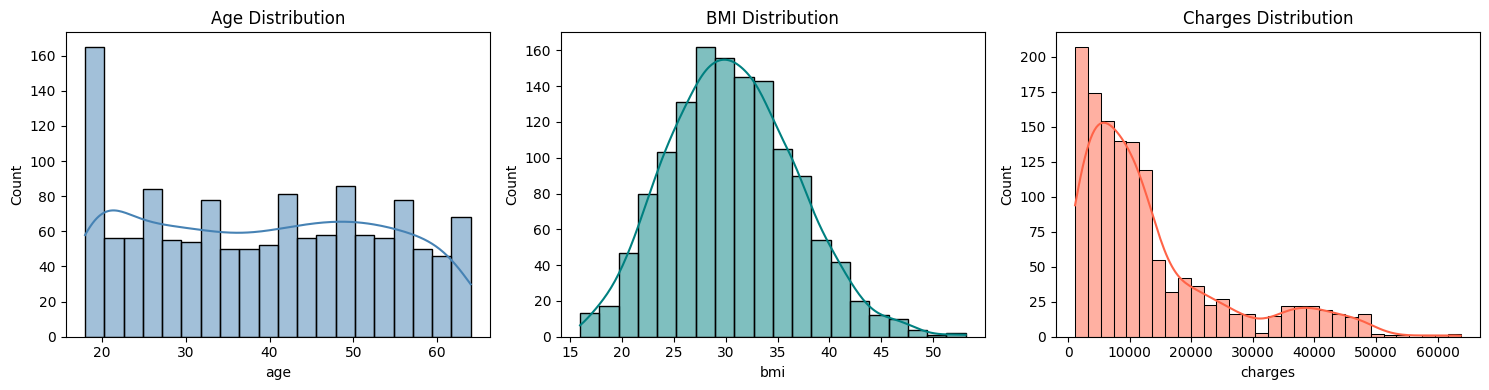

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(df['age'],     bins=20, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Age Distribution')

sns.histplot(df['bmi'],     bins=20, kde=True, ax=axes[1], color='teal')
axes[1].set_title('BMI Distribution')

sns.histplot(df['charges'], bins=30, kde=True, ax=axes[2], color='tomato')
axes[2].set_title('Charges Distribution')

plt.tight_layout()
plt.show()

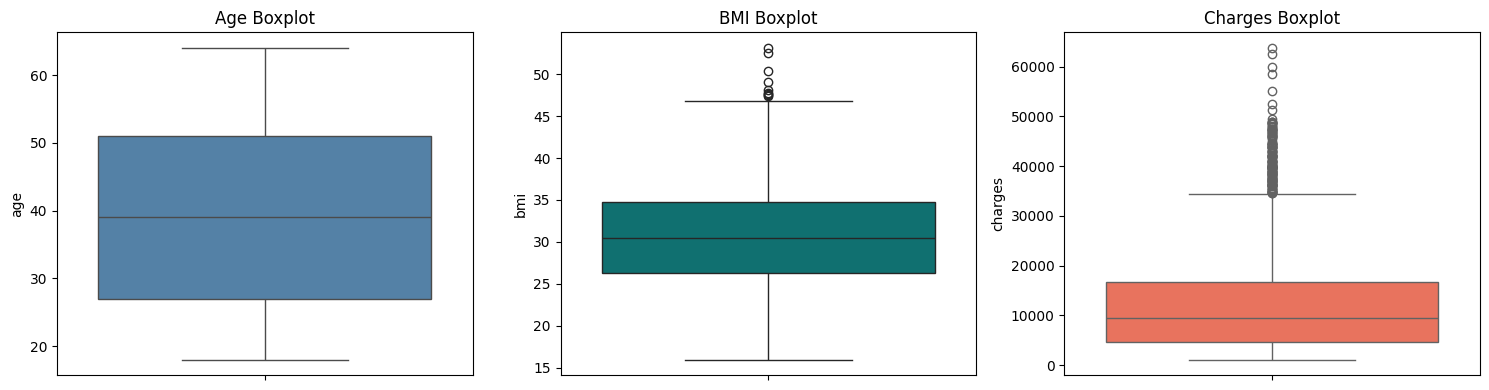

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.boxplot(df['age'],     ax=axes[0], color='steelblue')
axes[0].set_title('Age Boxplot')

sns.boxplot(df['bmi'],     ax=axes[1], color='teal')
axes[1].set_title('BMI Boxplot')

sns.boxplot(df['charges'], ax=axes[2], color='tomato')
axes[2].set_title('Charges Boxplot')

plt.tight_layout()
plt.show()

/tmp/ipykernel_10143/295052541.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, ax=ax, palette='colorblind')
/tmp/ipykernel_10143/295052541.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, ax=ax, palette='colorblind')
/tmp/ipykernel_10143/295052541.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, ax=ax, palette='colorblind')


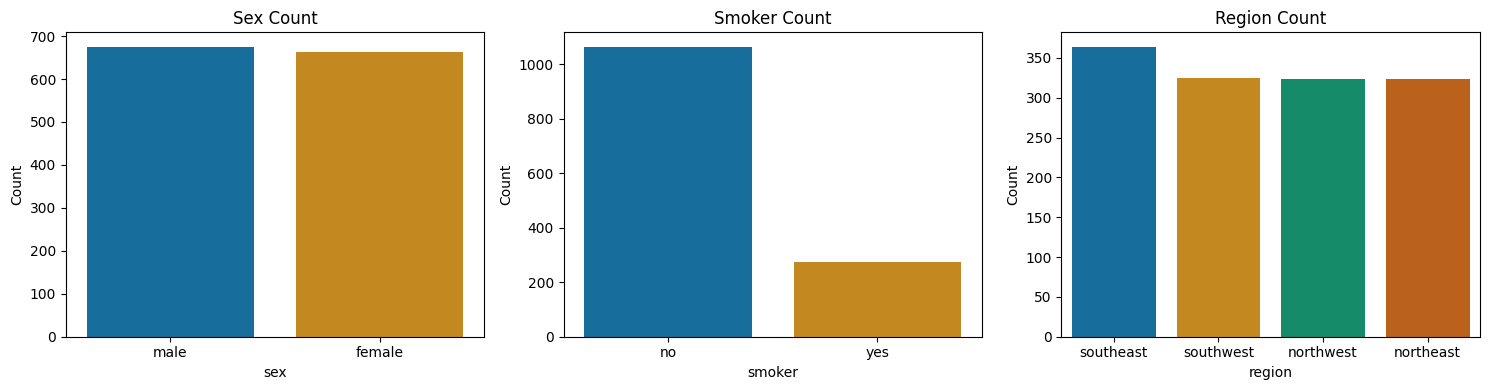

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['sex', 'smoker', 'region']):
    counts = df[col].value_counts()
    sns.barplot(x=counts.index, y=counts.values, ax=ax, palette='colorblind')
    ax.set_title(f'{col.title()} Count')
    ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

## 5. Bivariate Analysis

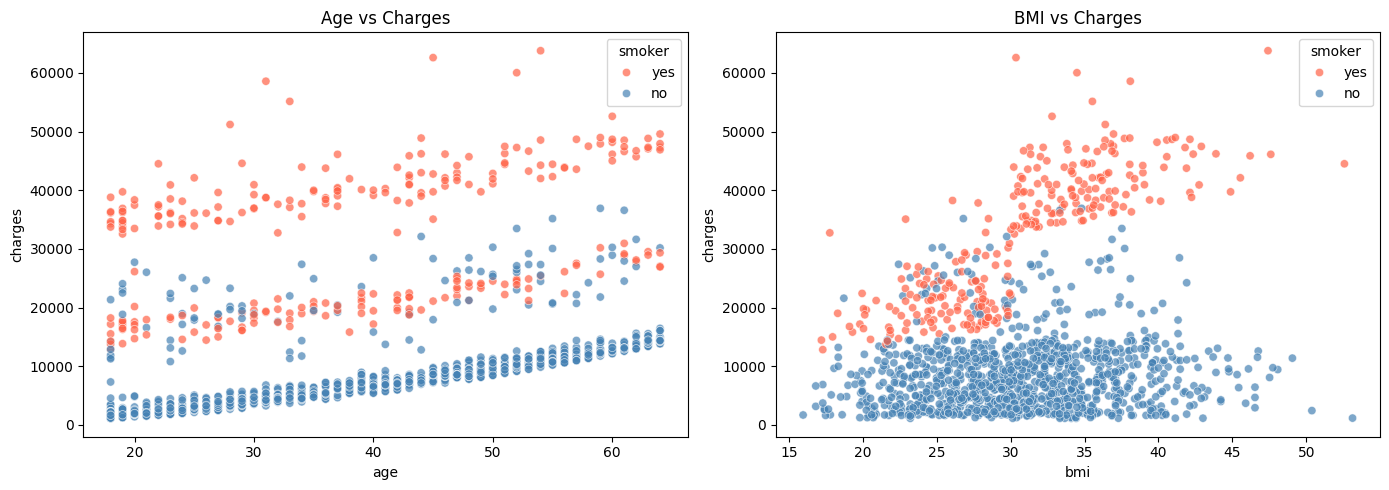

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=df, x='age', y='charges', hue='smoker',
                palette={'yes':'tomato','no':'steelblue'}, ax=axes[0], alpha=0.7)
axes[0].set_title('Age vs Charges')

sns.scatterplot(data=df, x='bmi', y='charges', hue='smoker',
                palette={'yes':'tomato','no':'steelblue'}, ax=axes[1], alpha=0.7)
axes[1].set_title('BMI vs Charges')

plt.tight_layout()
plt.show()

/tmp/ipykernel_10143/1691503718.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x=col, y='charges', palette='colorblind', ax=ax)
/tmp/ipykernel_10143/1691503718.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x=col, y='charges', palette='colorblind', ax=ax)
/tmp/ipykernel_10143/1691503718.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x=col, y='charges', palette='colorblind', ax=ax)


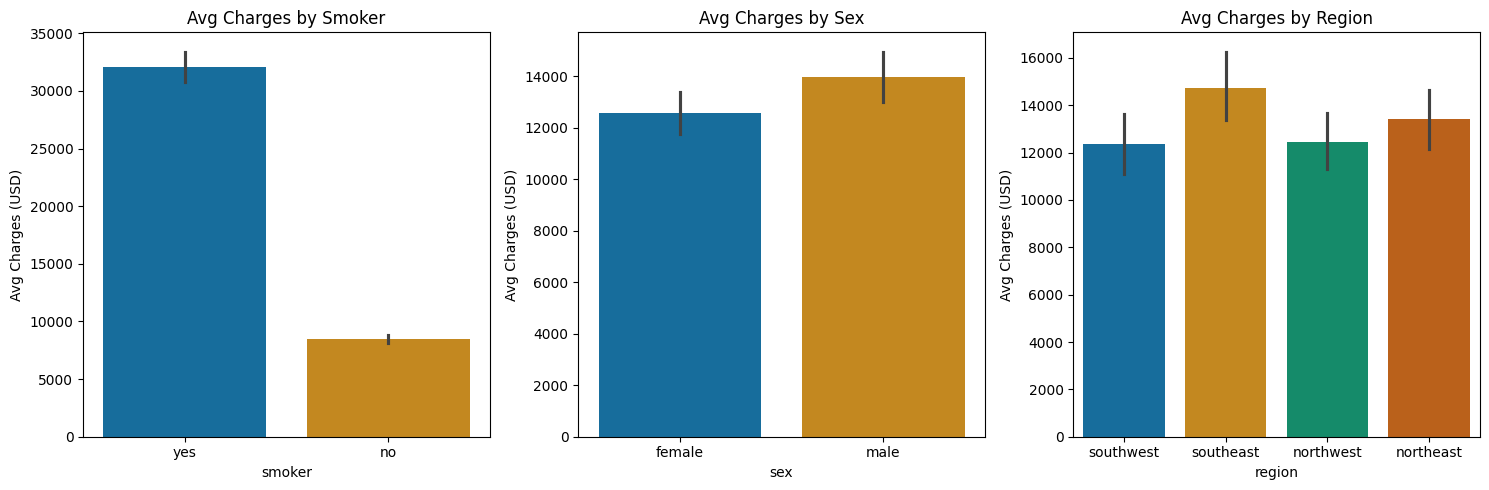

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col in zip(axes, ['smoker', 'sex', 'region']):
    sns.barplot(data=df, x=col, y='charges', palette='colorblind', ax=ax)
    ax.set_title(f'Avg Charges by {col.title()}')
    ax.set_ylabel('Avg Charges (USD)')

plt.tight_layout()
plt.show()

/tmp/ipykernel_10143/154746534.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='children', y='charges', palette='Blues_d')


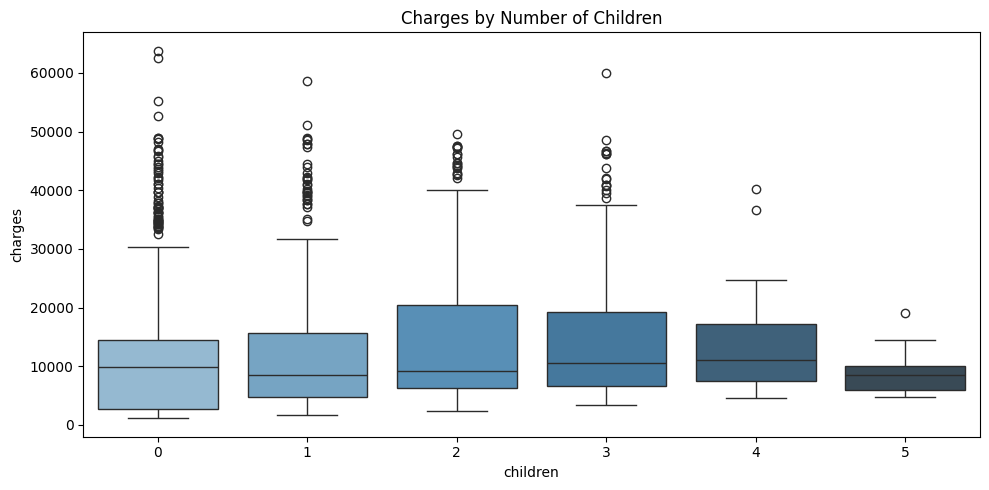

In [ ]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='children', y='charges', palette='Blues_d')
plt.title('Charges by Number of Children')
plt.tight_layout()
plt.show()

## 6. Feature Engineering

In [ ]:
# categorizing the bmi values as underweight,normal,overweight and obsesity.

df.sort_values(by='bmi',ascending=True).reset_index(drop=True,inplace=True)

conditions = [
    (df['bmi']<18.5),                       #underweight
    (df['bmi']>=18.5) & (df['bmi']<=25),    #normal
    (df['bmi']>25) & (df['bmi']<=29.9),     #overweight
    (df['bmi']>29.9)]                       #obesity

categories = ['underweight','normal','overweight','obesity']

df['bmi_category'] = np.select(conditions,categories,default='unknown')


df.head()

,age,sex,bmi,children,smoker,region,charges,bmi_category
0,19,female,27.900,0,yes,southwest,16884.92400,overweight
1,18,male,33.770,1,no,southeast,1725.55230,obesity
2,28,male,33.000,3,no,southeast,4449.46200,obesity
3,33,male,22.705,0,no,northwest,21984.47061,normal
4,32,male,28.880,0,no,northwest,3866.85520,overweight


<Axes: xlabel='age_group', ylabel='charges'>

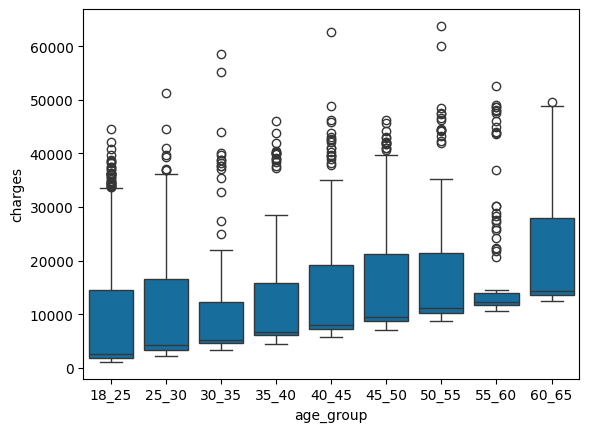

In [ ]:
#feature engineering ---adding one more column age groups
# #-----using cut() function bcz to creating numerical to cateforical from age groups
df['age_group'] = pd.cut(
    df['age'],
    bins=[17,25,30,35,40,45,50,55,60,65],
    labels=['18_25','25_30','30_35','35_40','40_45','45_50','50_55','55_60','60_65'],
    right=True
)
#df.groupby('age')[]
sns.boxplot(x='age_group', y='charges', data=df)

In [ ]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges',
       'bmi_category', 'age_group'],
      dtype='object')

/tmp/ipykernel_10143/515838515.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='age_group', y='charges', palette='coolwarm', ax=axes[0])
/tmp/ipykernel_10143/515838515.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='bmi_category', y='charges', palette='magma', ax=axes[1])


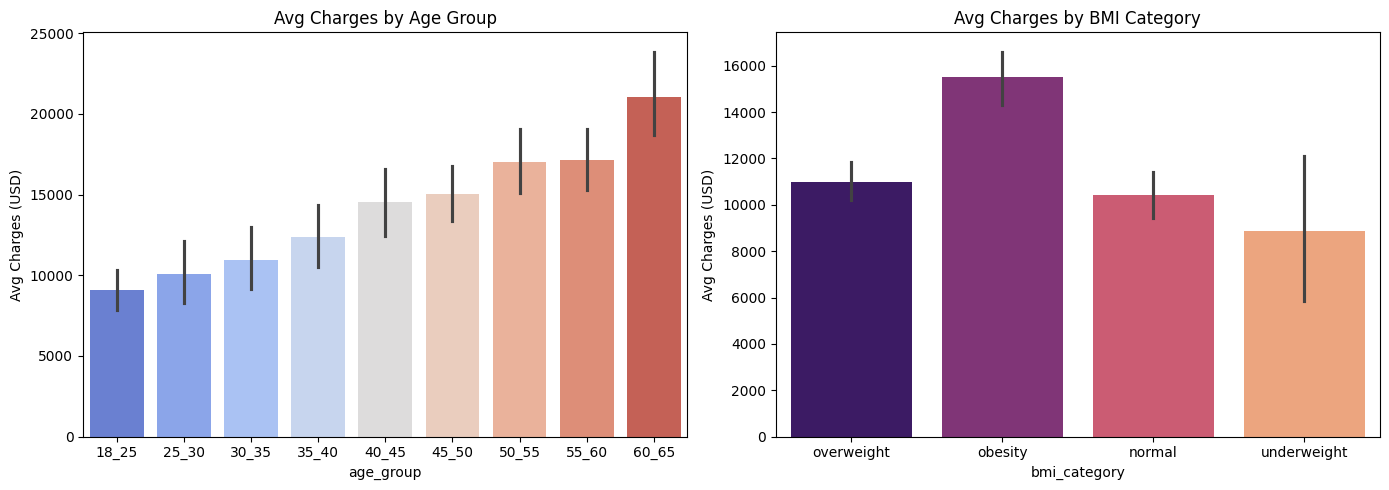

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=df, x='age_group', y='charges', palette='coolwarm', ax=axes[0])
axes[0].set_title('Avg Charges by Age Group')
axes[0].set_ylabel('Avg Charges (USD)')

order = ['Underweight','Normal','Overweight','Obese']
sns.barplot(data=df, x='bmi_category', y='charges', palette='magma', ax=axes[1])
axes[1].set_title('Avg Charges by BMI Category')
axes[1].set_ylabel('Avg Charges (USD)')

plt.tight_layout()
plt.show()

# **Analysis From EDA**
# POINT TO BE NOTED
As you can see in age groups between `29 to 54` they are highly consuming cigarette and above `40,000` charges it shows that all are cigarette consumer so our majorly insurance takers are affecting from smoking so thats why they have to pay `[30 to 50%]` more than non-smoker contumers[link](https://www.google.com/search?client=opera&q=if+the+consumer+consume+smoking+products+so+the+charges+of+insurance+to+be+more&sourceid=opera&ie=UTF-8&oe=UTF-8)


# Key Insights
*   Insurance charges increase with age, but gradually
*   Smoking is the most significant factor affecting charges
*   Smokers have substantially higher costs than non-smokers
*   High-value outliers are mainly smokers, not data errors
*   Charges above `40,000` are predominantly from smokers
*   Age group `29–54` shows many high charges, driven by smokers

# Summary
*  Smoking is the primary driver of high insurance charges
*  Age plays a secondary role with gradual impact
*  Outliers represent real high-risk individuals and should be retained
*  For better risk assessment, insurers should:
*  *  Focus on smoking status
*  *  Use insights for pricing and customer segmentation

## 7. Correlation Heatmap

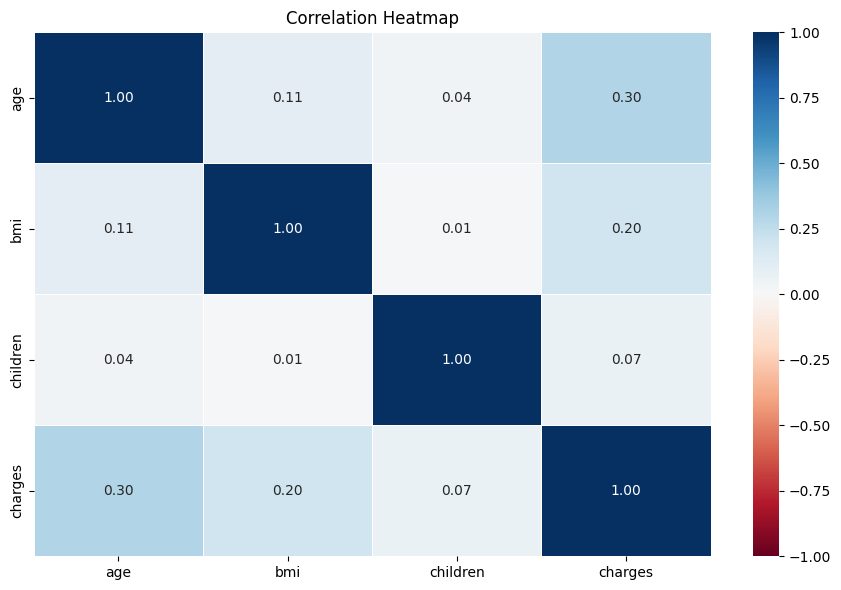

In [ ]:
plt.figure(figsize=(9, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt='.2f',
            cmap='RdBu', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

## 8. Preprocessing

In [ ]:
from sklearn.preprocessing import LabelEncoder

df.dropna(inplace=True)

# Apply Label Encoding to ordinal columns in df first
le = LabelEncoder()
df['bmi_category'] = le.fit_transform(df['bmi_category'])  # 0,1,2,3
df['age_group']    = le.fit_transform(df['age_group'])      # 0,1,2,3,4

# Now create X and y from the processed df
X = df.drop('charges', axis=1)
y = df['charges']

# Perform One-Hot Encoding only on the nominal columns in X
X = pd.get_dummies(X, columns=['sex', 'smoker', 'region'], drop_first=True)

# Clean column names
X.columns = X.columns.str.replace('[^A-Za-z0-9_]+', '_', regex=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Train:", X_train.shape)
print("Test: ", X_test.shape)
print("Features:", X.columns.tolist())

Train: (1069, 10)
Test:  (268, 10)
Features: ['age', 'bmi', 'children', 'bmi_category', 'age_group', 'sex_male', 'smoker_yes', 'region_northwest', 'region_southeast', 'region_southwest']


## 9. Linear Regression

In [ ]:
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

print("R2  :", round(r2_score(y_test, lr_pred), 4))
print("MAE :", round(mean_absolute_error(y_test, lr_pred), 2))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, lr_pred)), 2))

R2  : 0.8047
MAE : 4179.02
RMSE: 5991.03


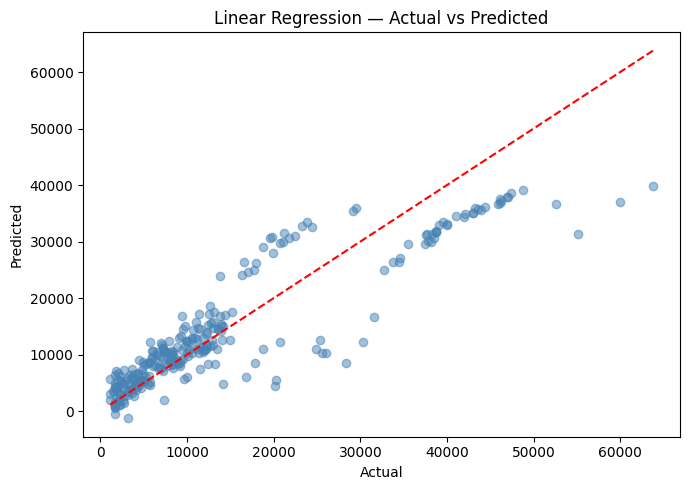

In [ ]:
plt.figure(figsize=(7, 5))
plt.scatter(y_test, lr_pred, alpha=0.5, color='steelblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title('Linear Regression — Actual vs Predicted')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.tight_layout()
plt.show()

## 10. Random Forest

In [ ]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print("R2  :", round(r2_score(y_test, rf_pred), 4))
print("MAE :", round(mean_absolute_error(y_test, rf_pred), 2))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, rf_pred)), 2))

R2  : 0.8802
MAE : 2641.49
RMSE: 4692.64


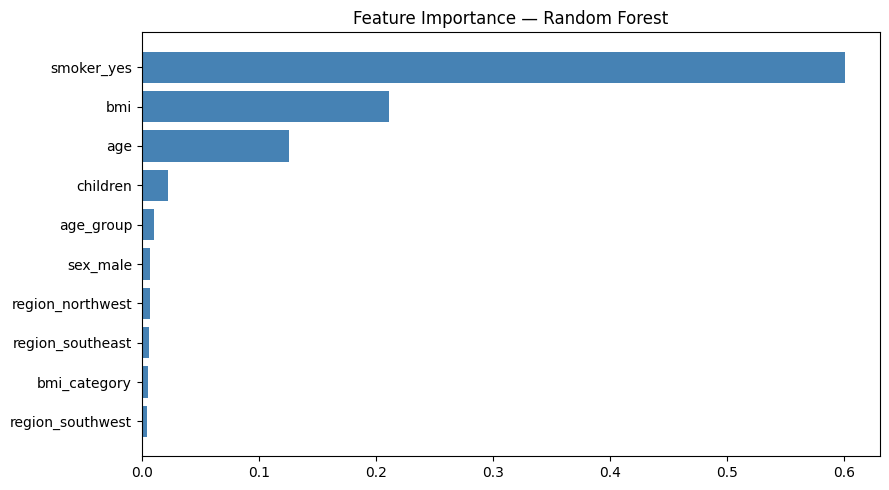

In [ ]:
fi = pd.DataFrame({'Feature': X.columns, 'Importance': rf.feature_importances_})
fi = fi.sort_values('Importance', ascending=True)

plt.figure(figsize=(9, 5))
plt.barh(fi['Feature'], fi['Importance'], color='steelblue')
plt.title('Feature Importance — Random Forest')
plt.tight_layout()
plt.show()

## 11. XGBoost

In [ ]:
xgb = XGBRegressor(n_estimators=100, learning_rate=0.05,
                   max_depth=4, random_state=42, verbosity=0)
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)

print("R2  :", round(r2_score(y_test, xgb_pred), 4))
print("MAE :", round(mean_absolute_error(y_test, xgb_pred), 2))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, xgb_pred)), 2))

R2  : 0.9024
MAE : 2441.13
RMSE: 4234.73


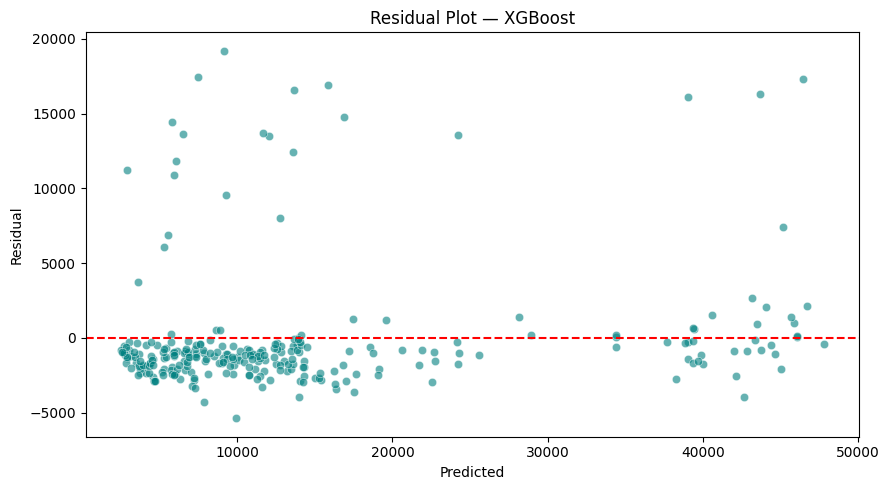

In [ ]:
residuals = y_test - xgb_pred

plt.figure(figsize=(9, 5))
sns.scatterplot(x=xgb_pred, y=residuals, alpha=0.6, color='teal')
plt.axhline(0, color='red', linestyle='--')
plt.title('Residual Plot — XGBoost')
plt.xlabel('Predicted')
plt.ylabel('Residual')
plt.tight_layout()
plt.show()

## 12. Model Comparison

In [ ]:
results = {
    'Model': ['Linear Regression', 'Random Forest', 'XGBoost'],
    'R2':    [round(r2_score(y_test, lr_pred), 4),
              round(r2_score(y_test, rf_pred), 4),
              round(r2_score(y_test, xgb_pred), 4)],
    'MAE':   [round(mean_absolute_error(y_test, p), 2) for p in [lr_pred, rf_pred, xgb_pred]],
    'RMSE':  [round(np.sqrt(mean_squared_error(y_test, p)), 2) for p in [lr_pred, rf_pred, xgb_pred]]
}

results_df = pd.DataFrame(results).sort_values('R2', ascending=False).reset_index(drop=True)
print(results_df.to_string(index=False))

            Model     R2     MAE    RMSE
          XGBoost 0.9024 2441.13 4234.73
    Random Forest 0.8802 2641.49 4692.64
Linear Regression 0.8047 4179.02 5991.03


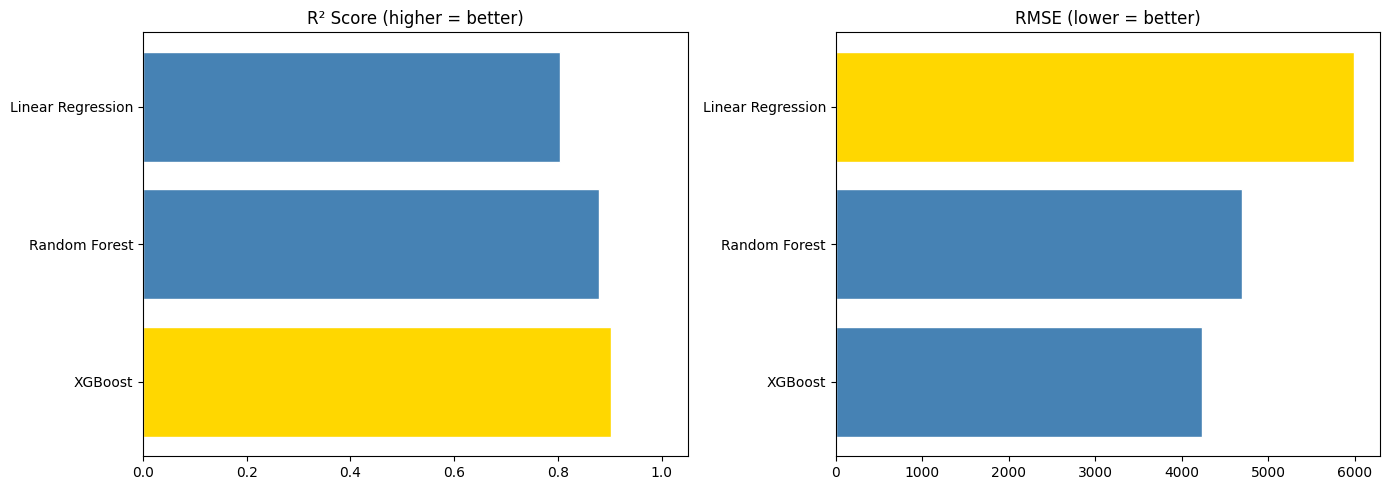

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['gold','steelblue','steelblue']
axes[0].barh(results_df['Model'], results_df['R2'], color=colors, edgecolor='white')
axes[0].set_title('R² Score (higher = better)')
axes[0].set_xlim(0, 1.05)

axes[1].barh(results_df['Model'], results_df['RMSE'], color=['gold','steelblue','steelblue'][::-1], edgecolor='white')
axes[1].set_title('RMSE (lower = better)')

plt.tight_layout()
plt.show()

best = results_df.iloc[0]